# Customer Retention Analysis and Prediction with Customer Churn Dataset

## Mini Project – Machine Learning
<p><strong>Customer churn</strong> is the term used to describe when customers end their relationship or subscription with a company or service provider. Churn affects businesses’ revenue, growth, and customer loyalty. By studying churn and its related features, companies can create ways to keep existing customers, make them happier, and lower churn rates. They can also use predictive models to anticipate and prevent future churn, and take action to keep customers who are likely to leave.

Customer retention is a critical business challenge, as acquiring new customers is often significantly more expensive than retaining existing ones. This project focuses on analyzing customer behavior and building a machine learning model to predict customer churn.

The goal is to identify key factors that influence customer churn and to develop a predictive model that can help businesses take proactive actions to retain valuable customers.


## Business Problem

Customer churn directly impacts revenue, growth, and long-term sustainability of a business. When customers leave, companies face increased acquisition costs and potential loss of brand loyalty.

By predicting churn in advance, businesses can:
- Identify at-risk customers
- Design targeted retention strategies
- Improve customer satisfaction
- Increase lifetime value


## Dataset Overview

Dataset used: <code>customer_churn_dataset-testing-master.csv</code> and <code>customer_churn_dataset-training-master.csv</code>, downloaded from Kaggle <a href="https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset">here</a>.</p>
<p>These datasets contains 12 feature columns. In detail, these are:
<br></p>
<ul>
    <li><b>CustomerID:</b> A unique identifier for each customer</li>
    <li><b>Age:</b> The age of the customer</li>
    <li><b>Gender:</b> Gender of the customer</li>
    <li><b>Tenure:</b> Duration in months for which a customer has been using the company's products or services</li>
    <li><b>Usage Frequency:</b> Number of times that the customer has used the company’s services in the last month</li>
    <li><b>Support Calls:</b> Number of calls that the customer has made to the customer support in the last month</li>
    <li><b>Payment Delay:</b> Number of days that the customer has delayed their payment in the last month</li>
    <li><b>Subscription Type:</b> Type of subscription the customer has choosen</li>
    <li><b>Contract Length:</b> Duration of the contract that the customer has signed with the company</li>
    <li><b>Total Spend:</b> Total amount of money the customer has spent on the company's products or services</li>
    <li><b>Last Interaction:</b> Number of days since the last interaction that the customer had with the company</li>
    <li><b>Churn:</b> Binary label indicating whether a customer has churned (1) or not (0)</li>
</ul>

## Importing Required Libraries

We import standard Python libraries for data manipulation, visualization, and machine learning. These tools help in exploring the data, preprocessing features, and building predictive models.


In [1]:
# Importing essential libraries for data analysis, visualization, and modeling

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

import pickle

from sklearn.tree import DecisionTreeClassifier

## Data Loading

The dataset is loaded into a pandas DataFrame to enable structured analysis and preprocessing. Initial inspection helps verify data integrity and column structure.


In [2]:
# The dataset is not relly split in a balanced way. So, I'll import train and test data
# as a single data and split it later

df = pd.concat(
    [
        pd.read_csv('customer_churn_dataset-training-master.csv'), 
        pd.read_csv('customer_churn_dataset-testing-master.csv')
    ], 
    axis=0)
df.reset_index(drop=True, inplace=True)
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [3]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## Initial Dataset Preprocessing

In [4]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [5]:
df.drop(columns='CustomerID', inplace=True) # removing unnecessary colum

df.columns = [col.lower().replace(' ', '_') for col in df.columns] # renaming the column names 

In [6]:
df.dropna(inplace=True) # Removing the single missing value row

In [7]:
df.shape

(505206, 11)

In [8]:
descrete_col = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']
for col in descrete_col:
    df[col] = df[col].astype(int)
df

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1
...,...,...,...,...,...,...,...,...,...,...,...
505202,45,Female,33,12,6,21,Basic,Quarterly,947.0,14,1
505203,37,Male,6,1,5,22,Standard,Annual,923.0,9,1
505204,25,Male,39,14,8,30,Premium,Monthly,327.0,20,1
505205,50,Female,18,19,7,22,Standard,Monthly,540.0,13,1


# EDA: Exploratory Data Analysis

## Univarient Analysis

In [9]:
# Creating custom functions to visualize features
import math

def make_histogram(df, target_feature, bins = 10, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    plt.hist(df[target_feature], bins=bins)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.ylabel('Count')
    plt.xlabel(target_feature)
    plt.title(f"Distribution of {target_feature.lower()}{additional}:\n")
    plt.grid()
    plt.show()
    print(f"Distribution of {target_feature.lower()}{additional}: {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n{df[target_feature].skew():.3f} Skewness\n")

def make_piechart(df, row, additional=''):
    n_features = len(row)
    n_cols = 2
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
    axes = axes.flatten()

    palette_color = sns.color_palette('bright')

    for idx, feature in enumerate(row):
        value_counts = df[feature].value_counts()
        data = value_counts.values
        keys = value_counts.index

        axes[idx].pie(
            data,
            labels=keys,
            colors=palette_color,
            autopct='%.0f%%',
            startangle=90
        )
        axes[idx].set_title(f"Distribution of Customer's {feature}")

        # Optional text summary
        print_str = f"Distribution of customer's {feature.lower()}{additional}:"
        for k, v in zip(keys, data):
            print_str += f"\n{v} {k}"
        print(print_str)
        print()

def make_barplot(df, target_feature, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())
    plt.bar(keys, data)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.xlabel(f'{target_feature.capitalize()}{additional}')
    plt.ylabel('Frequency')
    plt.title(f"Distribution of cutomer's {target_feature.lower()}{additional}\n")
    plt.grid(axis='y')
    plt.show()
    print(f"Distribution of cutomer's {target_feature.lower()}{additional}: {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n\n{df[target_feature].skew():.3f} Skewness\n")
    
def make_boxplot(df, feature):
    plt.figure(figsize=(10,5))
    sns.boxplot(df, x=feature)
    plt.title(f"Boxplot of {feature}\n")
    plt.xlabel(feature)
    plt.ylabel("Values")
    plt.show()

<Figure size 1500x1000 with 0 Axes>

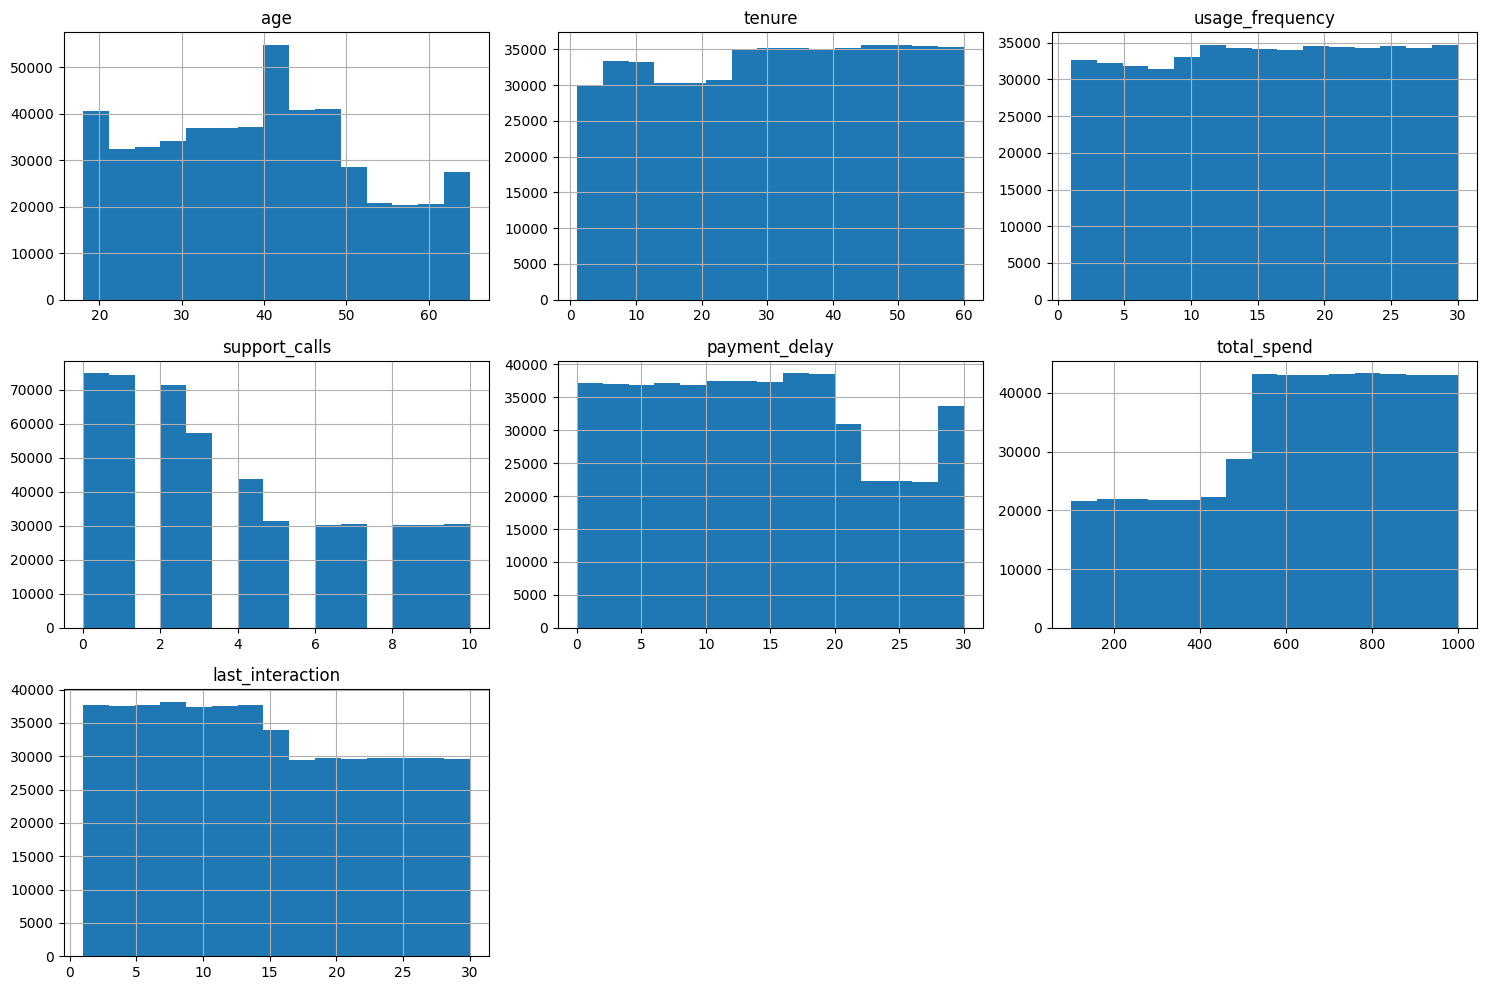

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude target and discrete integer-like columns
exclude = ["churn"]  # add more if needed , "Payment Delay"
numeric_continuous = [col for col in numeric_cols if col not in exclude]

# Plot histograms for continuous numeric columns to check distribution
plt.figure(figsize=(15, 10))
df[numeric_continuous].hist(bins=15, figsize=(15, 10), layout=(3, 3))
plt.tight_layout()
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'>The data is spread out evenly across the board, no weird spikes or dips, just a nice, consistent spread.</div>

Distribution of customer's gender:
280273 Male
224933 Female

Distribution of customer's subscription_type:
170630 Standard
170099 Premium
164477 Basic

Distribution of customer's contract_length:
198608 Annual
197364 Quarterly
109234 Monthly

Distribution of customer's churn_category:
280492 Churn
224714 Not Churned



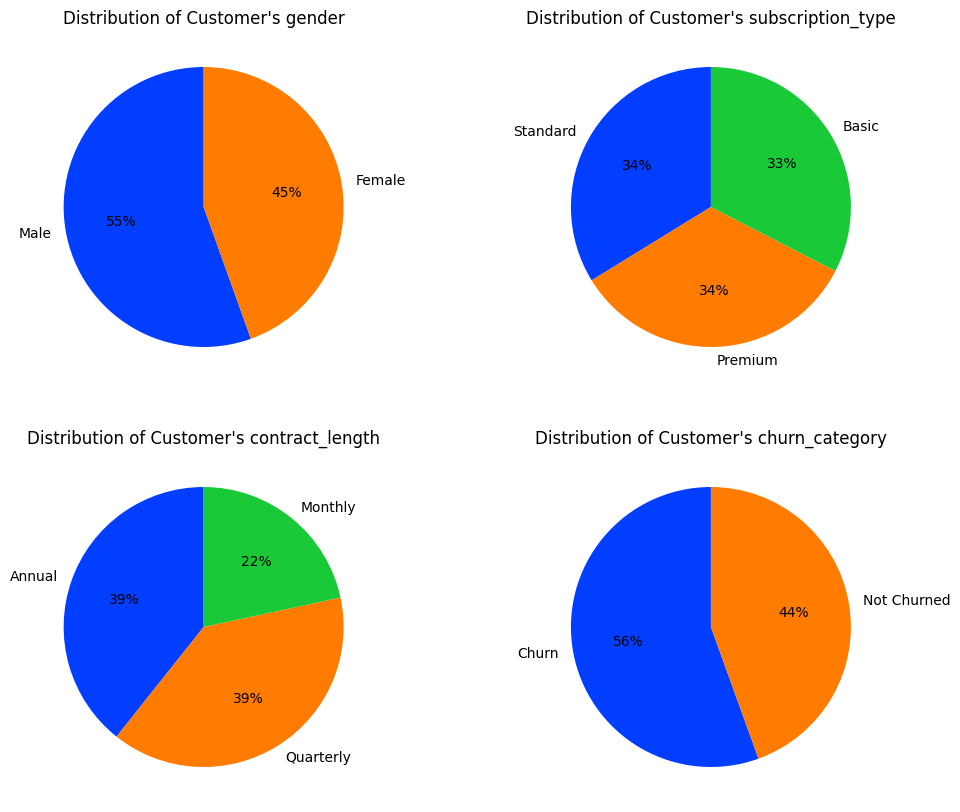

In [11]:
filtered = df.copy()
filtered['churn_category'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df['churn']]

make_piechart(filtered, ['gender','subscription_type','contract_length','churn_category'])


<div style='background-color: #efefef; color: black; padding: 1%'> The categorial columns are well balanced.</div>


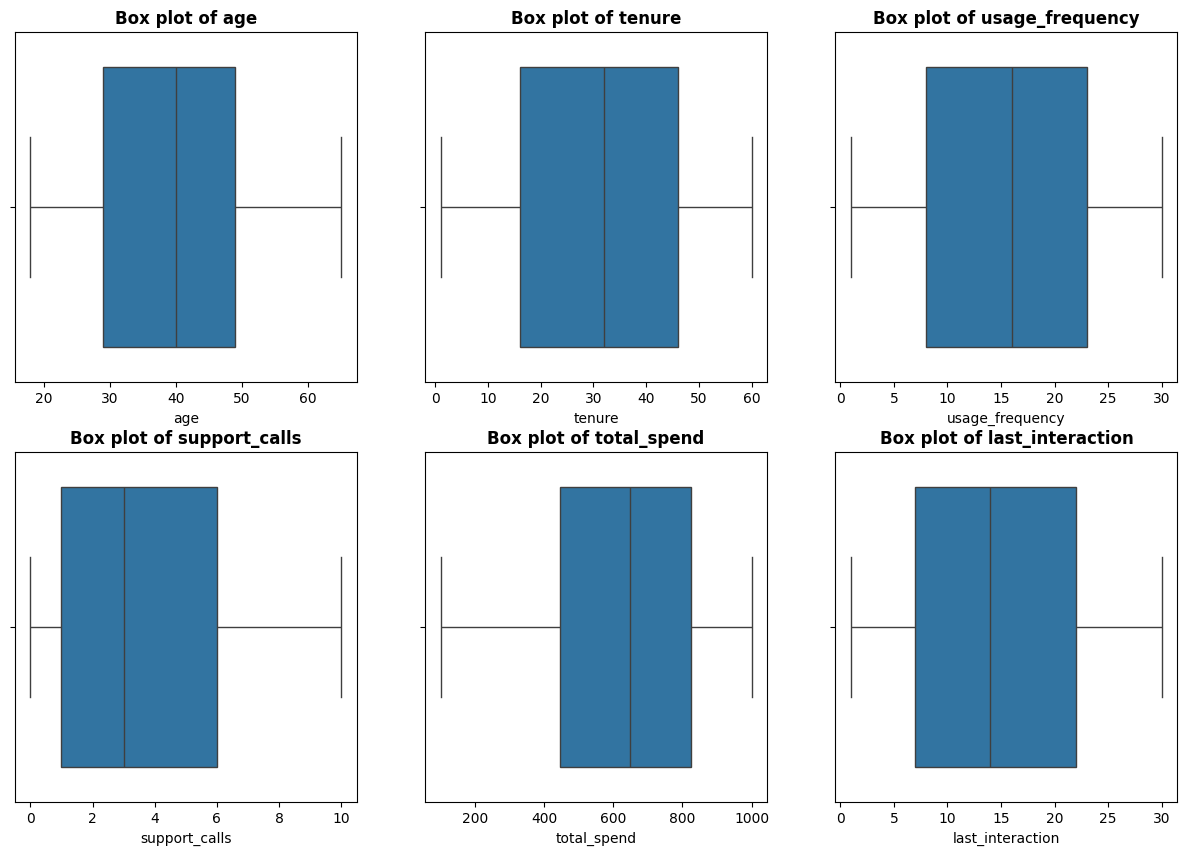

In [12]:
numeric_cols = ["age", "tenure", "usage_frequency", "support_calls", 
                "total_spend", "last_interaction"]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Create box plots for each numeric column
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Box plot of {col}', fontweight='bold')



<div style='background-color: #efefef; color: black; padding: 1%'>The box plot shows, there are no outliers in the dataset.</div>

## Bivariate Analysis

### Do gender and churn rate have any relationship?

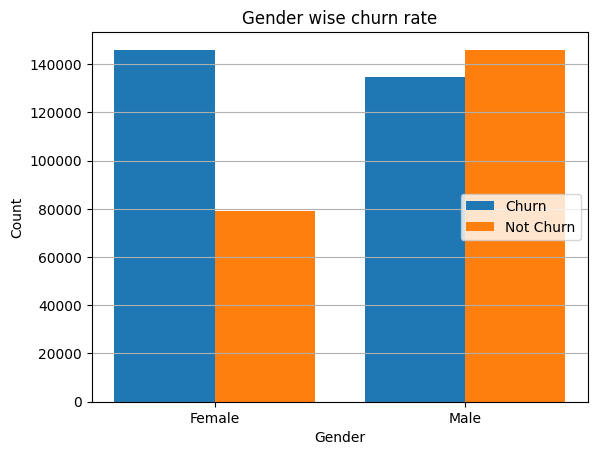

In [13]:
gender_churn = df.groupby(['gender', 'churn']).size().unstack()

X = list(gender_churn.index)
churn_0 = list(gender_churn.iloc[:, 0])
churn_1 = list(gender_churn.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title("Gender wise churn rate")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'>Yes, gender and churn rate have relationship. <br><br>Female customers exhibit a slightly higher churn rate compared to male customers. Active male customers (non-churned) is nearly double that of female customers.</div>

### Are there any noticeable trends in payment delays among customers who churned?

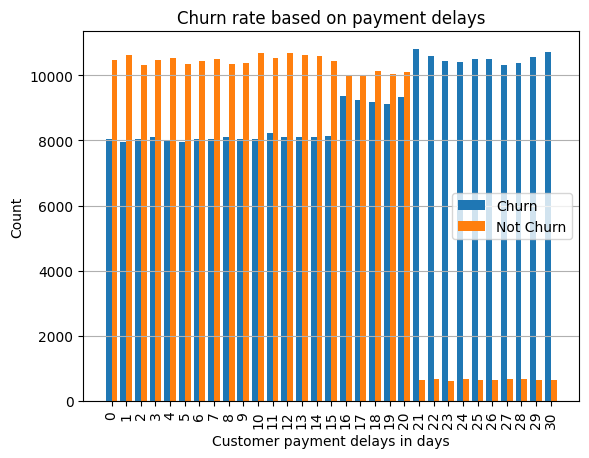

In [14]:
filtered = df.groupby(['payment_delay', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer payment delays in days")
plt.ylabel('Count')
plt.title("Churn rate based on payment delays")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'>Customers who are not churned tend to have higher payment delay days as compared with churned customers till day 20, after which churned customers have payment delays just over 10 times than that of not churned customers.</div>

### What is the distribution of usage frequency for churned vs. non-churned customers?

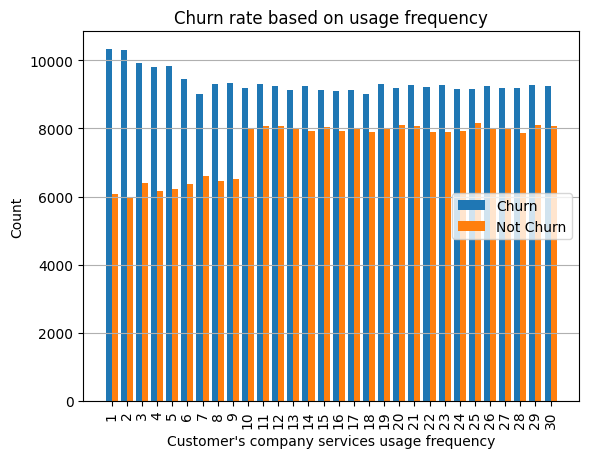

In [15]:
filtered = df.groupby(['usage_frequency', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer's company services usage frequency")
plt.ylabel('Count')
plt.title("Churn rate based on usage frequency")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'> Churned customer tend to use company's services significantly more than customers who are not churned.</div>

### Are customers with longer tenures less likely to churn?

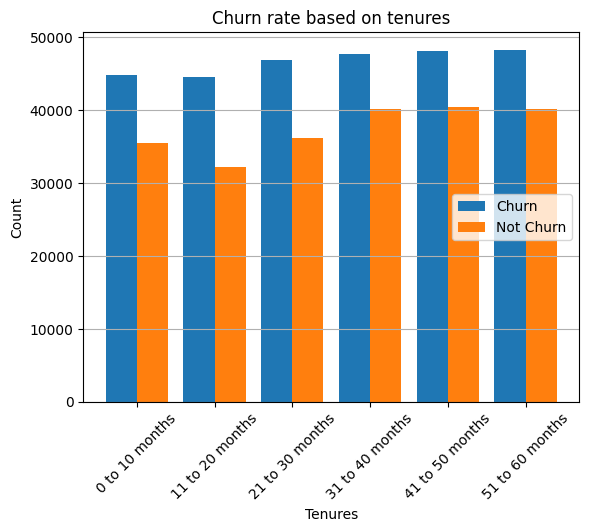

In [16]:
def categorize_age(age):
    if 0 <= age <= 10:
        return '0 to 10 months'
    elif 11 <= age <= 20:
        return '11 to 20 months'
    elif 21 <= age <= 30:
        return '21 to 30 months'
    elif 31 <= age <= 40:
        return '31 to 40 months'
    elif 41 <= age <= 50:
        return '41 to 50 months'
    elif 51 <= age <= 60:
        return '51 to 60 months'
    else:
        pass # For nan values

filtered = df.copy()
filtered['tenure_segmentation'] = df['tenure'].apply(categorize_age)
filtered = filtered.groupby(['tenure_segmentation', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Tenures')
plt.ylabel('Count')
plt.title("Churn rate based on tenures")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'>No, customers with longer tenures are more likely to churn.</div>

### Do customers with more support calls tend to churn more?

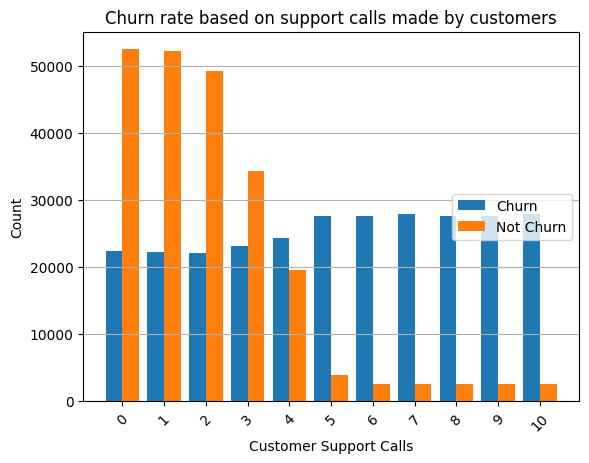

In [17]:
filtered = df.groupby(['support_calls', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Customer Support Calls')
plt.ylabel('Count')
plt.title("Churn rate based on support calls made by customers")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'>Yes, customers with more support calls tend to churn more. <br><br>On the contrary, customers who are not churned tend to make much more 0 to 3 customer support calls than churned customers, after which churned customers make significantly more calls.</div>

### Does the subscription type influence the churn rate?

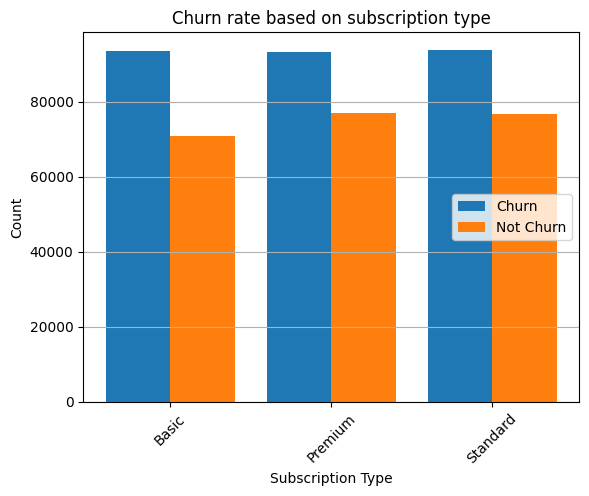

In [18]:
filtered = df.groupby(['subscription_type', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.title("Churn rate based on subscription type")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'>No, the subscription type does not influence customer churn rate. <br><br>Customers who are not churned tend to choose premium or standard subscription type slightly more than basic subscription.</div>

### Is there a pattern in contract length for customers who churned?

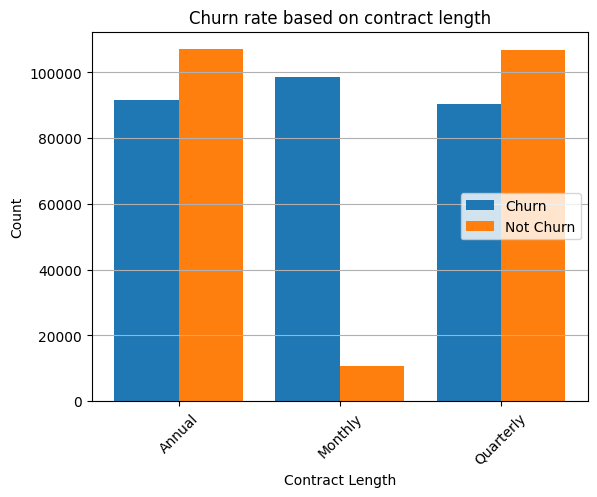

In [19]:
filtered = df.groupby(['contract_length', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])
  
X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')
  
plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Contract Length')
plt.ylabel('Count')
plt.title("Churn rate based on contract length")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'>Customers with quarterly contract lengths have the lowest churn rate, while those with monthly contract lengths exhibit the highest churn rate. Conversely, customers who do not churn overwhelmingly prefer annual and quarterly contracts over monthly contracts.</div>

### Is there a correlation between total spend and churn rate?

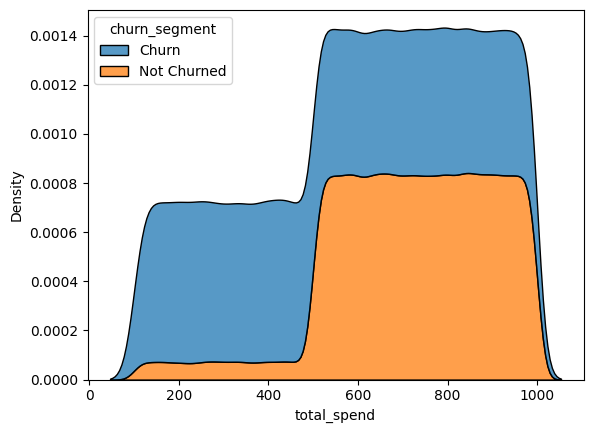

In [20]:
filtered = df.copy()
filtered['churn_segment'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df['churn']]

sns.kdeplot(data=filtered, x="total_spend", hue="churn_segment", multiple="stack")
plt.show()


<div style='background-color: #efefef; color: black; padding: 1%'>Customers who churn tends to spend significantly more money than those who don't.<br><br>Both churn and not churned customers share common total spending distribution / total spending behavior.</div>

## Correlation

## Independent Features Correlation

In [21]:
df[df.duplicated()]
independent_features_df = df.select_dtypes(include=['number']).copy().drop(columns=['churn'])


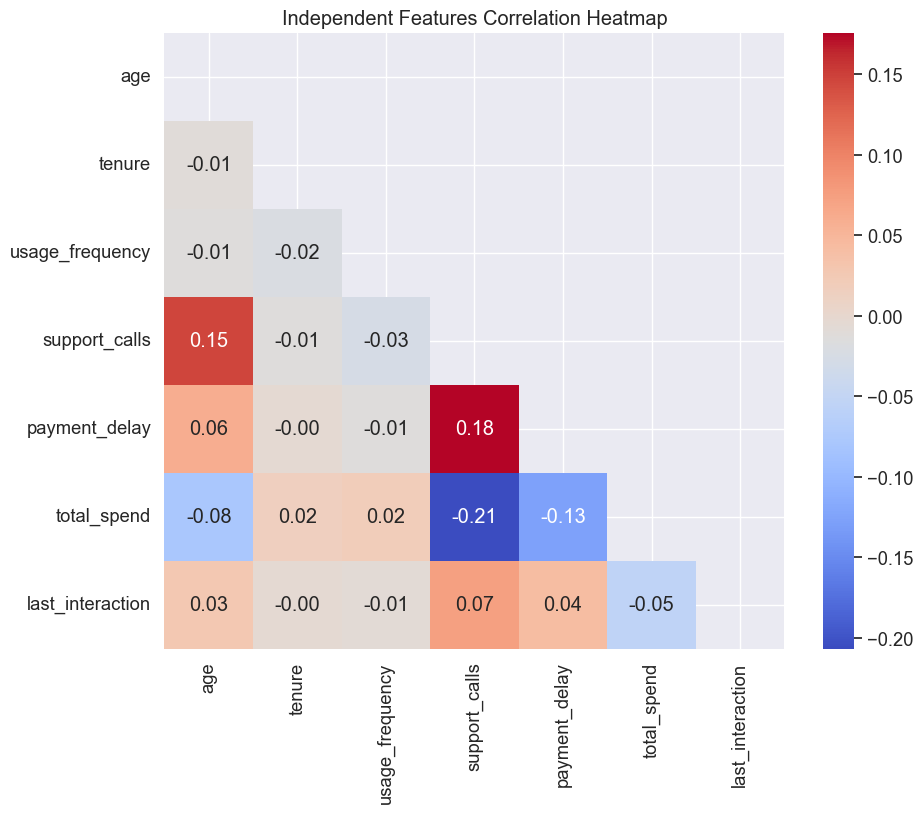

In [22]:
corr_matrix = independent_features_df.corr()

# Creating a mask to hide the upper triangle of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", mask=mask)
plt.title("Independent Features Correlation Heatmap")
plt.show()


## Inpedendent features correlation with prediction labels

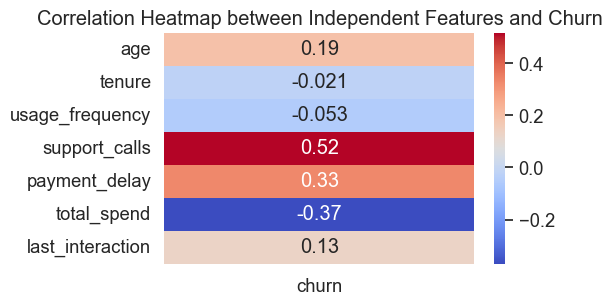

In [23]:
correlation_data = df.select_dtypes(include=['number']).corr().loc[:'last_interaction', 'churn']


# Create a heatmap
plt.figure(figsize=(5, 3))
sns.set(font_scale=1.2)
sns.heatmap(correlation_data.to_frame(), annot=True, cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap between Independent Features and Churn")
plt.show()



# Data Preparation

## Null values

**Missing values were dropped pre EDA because there was just a single row of missing values which before performing analysis won't affect result of analysis.**

## Encoding Categorical Data

### Label Encoding

In [24]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [25]:

df['subscription_type'] = le.fit_transform(df['subscription_type'])
df.head()

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,30,0,39,14,5,18,2,Annual,932.0,17,1
1,65,0,49,1,10,8,0,Monthly,557.0,6,1
2,55,0,14,4,6,18,0,Quarterly,185.0,3,1
3,58,1,38,21,7,7,2,Monthly,396.0,29,1
4,23,1,32,20,5,8,0,Monthly,617.0,20,1


### One Hot Encoding for Contract Length because EDA showed that monthly contracts exhibit significantly higher churn.

In [26]:
df = pd.get_dummies(df, columns=['contract_length'], dtype=int)

In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 505206
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        505206 non-null  int64  
 1   gender                     505206 non-null  int64  
 2   tenure                     505206 non-null  int64  
 3   usage_frequency            505206 non-null  int64  
 4   support_calls              505206 non-null  int64  
 5   payment_delay              505206 non-null  int64  
 6   subscription_type          505206 non-null  int64  
 7   total_spend                505206 non-null  float64
 8   last_interaction           505206 non-null  int64  
 9   churn                      505206 non-null  int64  
 10  contract_length_Annual     505206 non-null  int64  
 11  contract_length_Monthly    505206 non-null  int64  
 12  contract_length_Quarterly  505206 non-null  int64  
dtypes: float64(1), int64(12)
memory us

# Training

## Train-Test Split
The dataset is split into training and testing sets. The training set is used to build the model, while the test set evaluates its performance on unseen data.


In [28]:
y = df['churn']
X = df.drop(columns='churn')

In [29]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model Training

The Decision Tree model is trained using the training dataset. During training, the model learns patterns that distinguish churned customers from retained customers.


In [30]:
dt_model = DecisionTreeClassifier(random_state=42,max_depth=10, min_samples_split=2)

dt_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n


## Model Evaluation

We evaluate the model using accuracy, confusion matrix, and classification metrics. These metrics help assess how well the model predicts customer churn.

In [31]:
y_pred = dt_model.predict(X_test)
y_pred_train = dt_model.predict(X_train)

In [32]:
print(f"Accuracy: {accuracy_score(y_pred, y_test) * 100:.2f}%")
print(classification_report(y_pred, y_test))


Accuracy: 93.22%
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     38856
           1       0.99      0.90      0.94     62186

    accuracy                           0.93    101042
   macro avg       0.92      0.94      0.93    101042
weighted avg       0.94      0.93      0.93    101042



## Confusion Matrix Analysis

The confusion matrix provides detailed insight into correct and incorrect predictions:
- True Positives: Correctly predicted churned customers
- False Positives: Incorrectly predicted churn
- False Negatives: Missed churn cases
- True Negatives: Correctly predicted retained customers


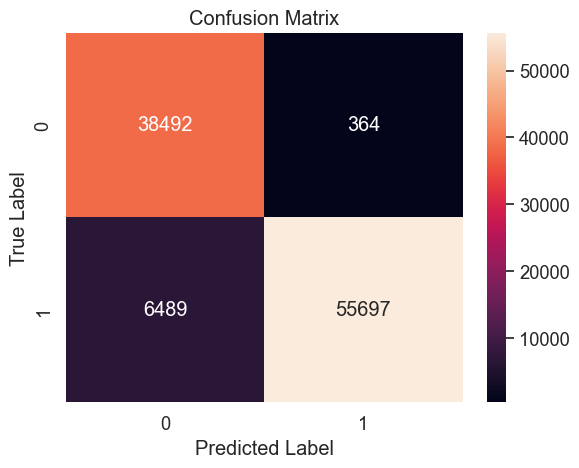

In [33]:
cm = confusion_matrix(y_pred, y_test)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Feature Importance

Feature importance analysis highlights the most influential factors contributing to customer churn. This insight is valuable for business teams to focus on high-impact retention strategies.


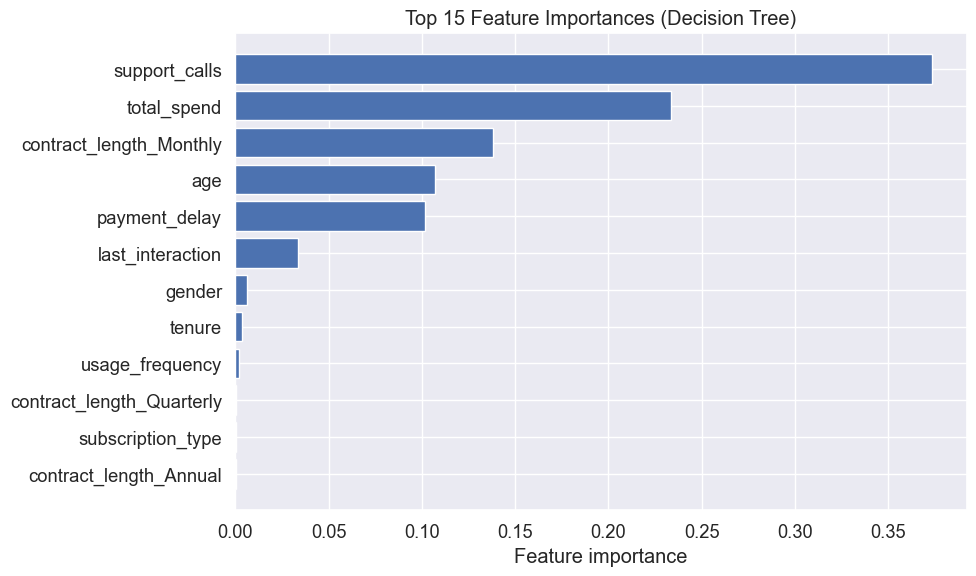

,feature,importance
4,support_calls,0.373486
7,total_spend,0.233840
10,contract_length_Monthly,0.137963
0,age,0.107316
5,payment_delay,0.101589
8,last_interaction,0.033812
1,gender,0.006393
2,tenure,0.003370
3,usage_frequency,0.001841
11,contract_length_Quarterly,0.000140


In [34]:
# Extract and visualize feature importance from the model

# Get feature importances
importances = dt_model.feature_importances_
feature_names = X_train.columns

# Create sorted dataframe
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Plot top N
top_n = 15
fi_top = fi.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(fi_top["feature"][::-1], fi_top["importance"][::-1])
plt.xlabel("Feature importance")
plt.title(f"Top {top_n} Feature Importances (Decision Tree)")
plt.tight_layout()
plt.show()

# Optional: print table
fi.head(20)

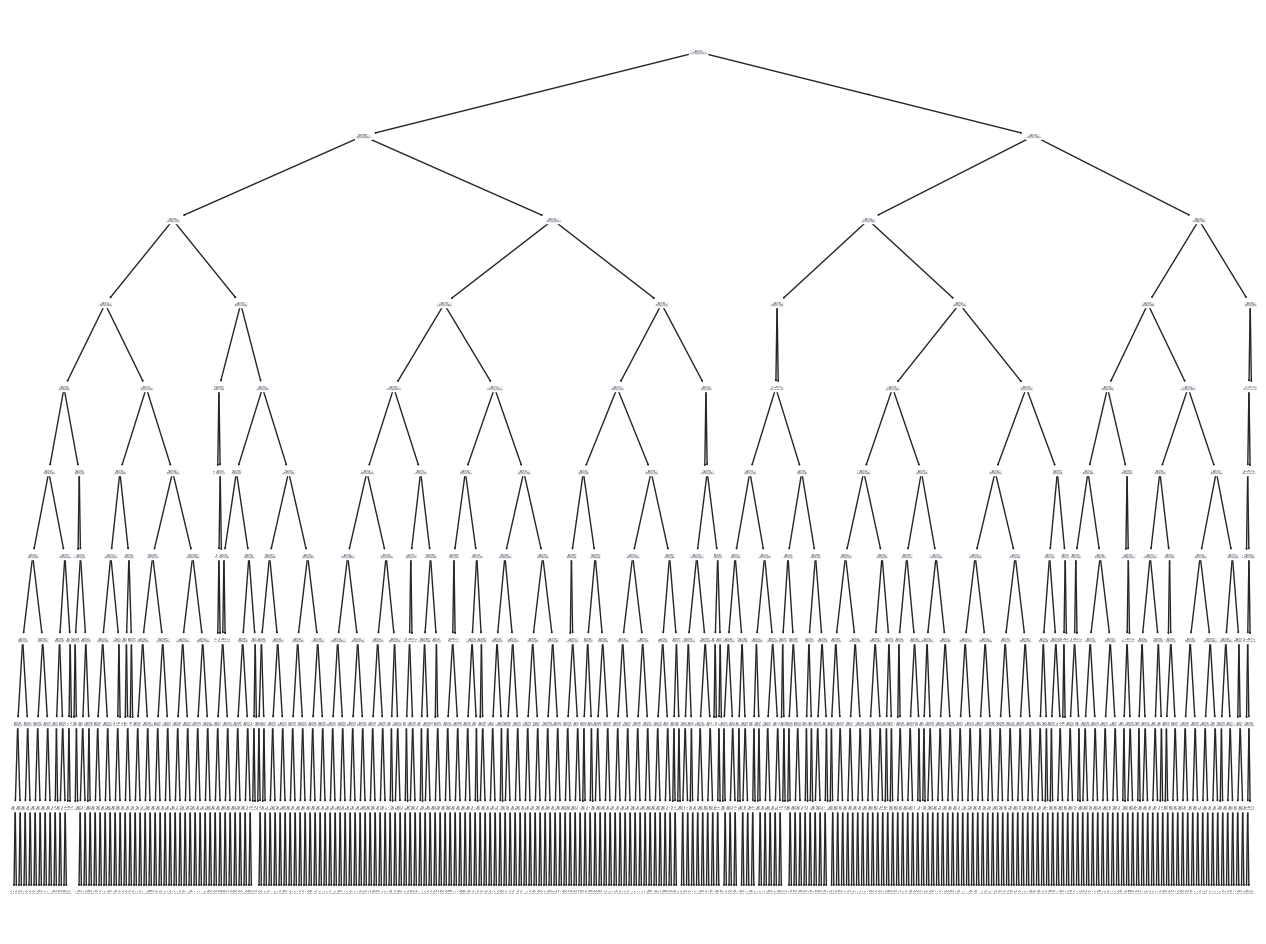

In [35]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 12))
plot_tree(dt_model)
plt.show()


## Business Insights

Based on the model and feature importance analysis:
- Customers with frequent support calls show higher churn risk
- Short-term contracts are more likely to churn
- Subscription type plays a significant role in retention

These insights can guide targeted interventions and policy changes.


## Limitations

- Decision Trees may overfit if not properly tuned
- The model may not capture complex patterns as effectively as ensemble methods
- Performance depends on data quality and feature representation


## Future Work

Although the current model achieves good performance, future improvements could include:
- Using ensemble models such as Random Forest for higher accuracy
- Applying cross-validation and hyperparameter tuning
- Incorporating customer interaction history and temporal features


## Conclusion

This project demonstrates how machine learning can be used to predict customer churn and support data-driven retention strategies. By identifying key churn drivers, businesses can take proactive steps to improve customer satisfaction and reduce churn rates.
